In [ ]:
/nfs/data/nii/data1/Analysis/GPUnet/ANALYSIS_incontext/SegFM3D/results/postchallenge_20250727_024854

In [233]:
from typing import final
from src.config import config
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
img_dir = os.path.join(config["DATA_DIR"], "3D_val_npz")
gts_dir = os.path.join(config["DATA_DIR"], "3D_val_gt_interactive_seg")
final_metrics = ['DSC_AUC', 'NSD_AUC', 'DSC_Final', 'NSD_Final',]

evalmetrics_june_df = pd.read_csv(os.path.join(config["RESULTS_DIR"], "simple", "norateam_metrics_2130_cases.csv"))    
#evalmetrics_current_df = pd.read_csv(os.path.join(config["RESULTS_DIR"], "postchallenge_20250728_152150", "norateam_metrics.csv"))
evalmetrics_current_df = pd.read_csv(os.path.join("/nfs/norasys/notebooks/camaret/segfm3d_nora_team/docker/submission/data/outputs/norateampostchallenge/norateampostchallenge_metrics.csv"))
evalmetrics_current_df['CaseName'] = evalmetrics_current_df['CaseName'].str.rstrip('.npz')
print(len(evalmetrics_june_df), len(evalmetrics_current_df))
print(evalmetrics_june_df[final_metrics].mean())
print(evalmetrics_current_df[final_metrics].mean())

2130 1819
DSC_AUC      2.479956
NSD_AUC      2.567132
DSC_Final    0.638593
NSD_Final    0.661417
dtype: float64
DSC_AUC      2.798344
NSD_AUC      2.997791
DSC_Final    0.743808
NSD_Final    0.802741
dtype: float64


In [234]:
#replace evalmetrics_june_df with evalmetrics_current_df entries when they exist
"""
evalmetrics_june_df.set_index("CaseName", inplace=True)
evalmetrics_current_df.set_index("CaseName", inplace=True)
evalmetrics_june_df.update(evalmetrics_current_df)
evalmetrics_june_df.reset_index(inplace=True)
"""

'\nevalmetrics_june_df.set_index("CaseName", inplace=True)\nevalmetrics_current_df.set_index("CaseName", inplace=True)\nevalmetrics_june_df.update(evalmetrics_current_df)\nevalmetrics_june_df.reset_index(inplace=True)\n'

In [235]:
# in evalmetrics_june_df, keep rows where 'CaseName' is in evalmetrics_current_df['CaseName']
evalmetrics_june_df = evalmetrics_current_df[['CaseName']].merge(
    evalmetrics_june_df, 
    on='CaseName', 
    how='inner'
)

In [236]:

evalmetrics_more_stats_df = pd.read_csv("stats_by_case.csv")
# add "has_bbox" and "modality" columns from evalmetrics_more_stats_df to evalmetrics_current_df, matching on 'CaseName'

evalmetrics_current_df = evalmetrics_current_df.merge(
    evalmetrics_more_stats_df[['CaseName', 'has_bbox', 'modality']],
    on='CaseName',
    how='left',
)
evalmetrics_june_df = evalmetrics_june_df.merge(
    evalmetrics_more_stats_df[['CaseName', 'has_bbox', 'modality']],
    on='CaseName',
    how='left',
)

In [237]:
evalmetrics_current_df

,CaseName,TotalRunningTime,RunningTime_1,RunningTime_2,RunningTime_3,RunningTime_4,RunningTime_5,RunningTime_6,DSC_AUC,NSD_AUC,...,NSD_1,NSD_2,NSD_3,NSD_4,NSD_5,NSD_6,num_class,runtime_upperbound,has_bbox,modality
0,CT_AMOS_amos_0018,80.470730,12.860479,13.519857,14.077994,12.998374,13.362801,13.651225,3.371821,3.704851,...,0.865152,0.903232,0.921177,0.927279,0.938556,0.932446,15,1350,True,CT
1,CT_AMOS_amos_0021,80.654077,14.041740,12.933618,13.390354,13.231964,13.276788,13.779613,3.309677,3.520297,...,0.777906,0.828384,0.874420,0.885953,0.898315,0.894833,14,1260,True,CT
2,CT_AMOS_amos_0033,80.879992,13.151828,12.792516,15.167135,13.347838,13.396732,13.023944,3.434495,3.739709,...,0.886640,0.919162,0.927088,0.936169,0.943636,0.946470,15,1350,True,CT
3,CT_AMOS_amos_0043,75.904191,12.871266,12.128947,12.559927,12.507241,12.349497,13.487313,3.363283,3.707839,...,0.886875,0.908654,0.920307,0.932328,0.931317,0.939120,15,1350,True,CT
4,CT_AMOS_amos_0044,89.201831,14.642744,14.353132,14.807744,14.739216,14.717495,15.941500,2.991055,3.288987,...,0.726266,0.776274,0.800363,0.837473,0.839253,0.847523,13,1170,True,CT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1814,MR_heart-ACDC_ACDC_patient076_frame01_lvrv,52.241175,8.463452,8.446721,8.643708,9.357941,8.489841,8.839511,3.721179,3.883828,...,0.937089,0.956388,0.969834,0.976350,0.972861,0.973178,2,180,True,MR
1815,MR_heart-ACDC_ACDC_patient076_frame01_myo,44.663846,0.000000,9.112786,10.309859,9.114695,8.029493,8.097013,0.850670,0.700418,...,0.000000,0.000000,0.000000,0.212275,0.295949,0.384388,1,90,False,MR
1816,MR_heart-ACDC_ACDC_patient077_frame09_lvrv,52.539468,8.438802,8.441818,8.576693,9.394770,9.091691,8.595694,2.947332,3.413949,...,0.683338,0.705191,0.775967,0.878029,0.934225,0.946265,2,180,True,MR
1817,MR_heart-ACDC_ACDC_patient077_frame09_myo,45.324871,0.000000,8.445934,8.785297,8.230173,9.912824,9.950643,0.696178,0.731960,...,0.000000,0.000000,0.000000,0.000000,0.456597,0.550726,1,90,False,MR


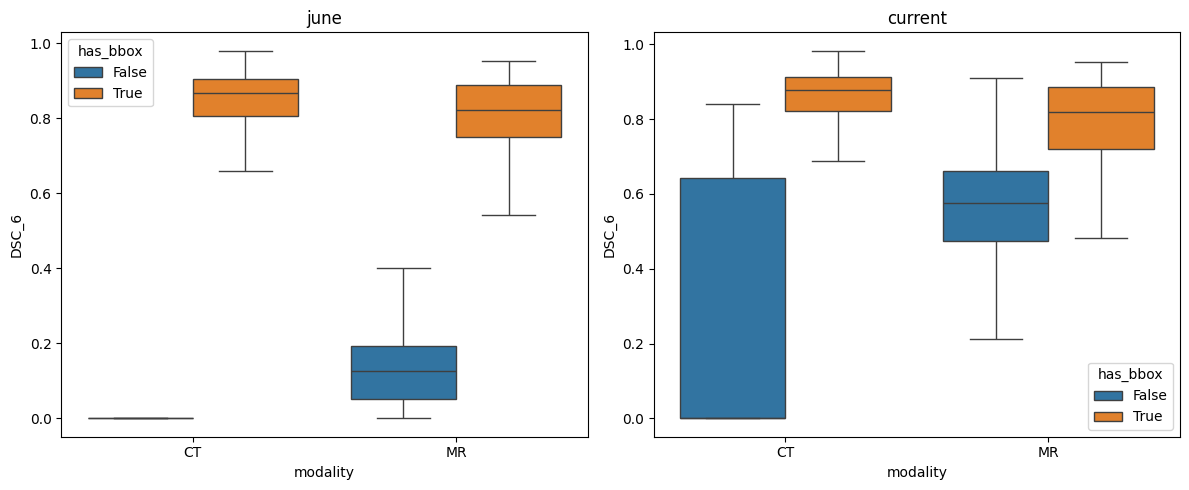

In [238]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=evalmetrics_june_df, x='modality', y='DSC_6', hue='has_bbox', 
            showfliers=False, ax=ax1)
ax1.set_title('june')
# Second boxplot
sns.boxplot(data=evalmetrics_current_df, x='modality', y='DSC_6', hue='has_bbox', 
            showfliers=False, ax=ax2)
ax2.set_title('current')

plt.tight_layout()
plt.show()

In [239]:
print( len(evalmetrics_current_df))


evalmetrics_june_df[final_metrics].mean(), evalmetrics_current_df[final_metrics].mean()

1819


(DSC_AUC      2.363873
 NSD_AUC      2.423711
 DSC_Final    0.610114
 NSD_Final    0.626318
 dtype: float64,
 DSC_AUC      2.798344
 NSD_AUC      2.997791
 DSC_Final    0.743808
 NSD_Final    0.802741
 dtype: float64)

In [240]:
evalmetrics_june_df[evalmetrics_june_df["has_bbox"] == False][final_metrics].mean(), evalmetrics_current_df[evalmetrics_current_df["has_bbox"] == False][final_metrics].mean()

(DSC_AUC      0.439904
 NSD_AUC      0.165151
 DSC_Final    0.140212
 NSD_Final    0.067017
 dtype: float64,
 DSC_AUC      1.760456
 NSD_AUC      1.893393
 DSC_Final    0.551396
 NSD_Final    0.605211
 dtype: float64)

In [241]:
evalmetrics_june_df[evalmetrics_june_df["has_bbox"] == True][final_metrics].mean(), evalmetrics_current_df[evalmetrics_current_df["has_bbox"] == True][final_metrics].mean()

(DSC_AUC      3.262243
 NSD_AUC      3.478312
 DSC_Final    0.829527
 NSD_Final    0.887475
 dtype: float64,
 DSC_AUC      3.282970
 NSD_AUC      3.513474
 DSC_Final    0.833652
 NSD_Final    0.894975
 dtype: float64)

In [242]:
evalmetrics_current_df[evalmetrics_current_df["has_bbox"] == False].shape

(579, 28)